#### 🛢️ Lithofacies Classification — FORCE 2020
##### 05 — Model Evaluation

---

👤 **Author:** NMM | 📅 **Date:** 2026 | 📁 **Input:** `best_model.pkl` - LightGBM

**Pipeline:** `00 Combination` → `01 Exploration` → `02 Preprocessing` → `03 EDA` → `04 Training` → **`05 Evaluation ◀`**

---

##### 📌 Objectives
1. Load best model and test data
2. Evaluate overall accuracy
3. Analyze per class performance
4. Plot confusion matrix
5. Plot feature importance
6. Analyze misclassifications
7. Test on unlabeled data
8. Generate final report

---

In [1]:
# Cell 1 - Imports & Load
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

sys.path.append("D:/Python/Lithofacies_Classification_NMM/src")
from config import *

# Load best model & data
model     = joblib.load(f"{MODEL_PATH}/best_model.pkl")
le_target = joblib.load(f"{MODEL_PATH}/le_target.pkl")
X_train, X_test, y_train, y_test = joblib.load(
                f"{MODEL_PATH}/train_test_split.pkl")

print("✅ Model & Data loaded!")
print(f"   Model    : LightGBM")
print(f"   Classes  : {list(le_target.classes_)}")
print(f"   Test rows: {len(X_test):,}")

✅ Config loaded!
✅ Model & Data loaded!
   Model    : LightGBM
   Classes  : ['Anhydrite', 'Coal', 'Igneous', 'Limestone', 'Marl', 'Sandstone', 'Shale', 'Tuff']
   Test rows: 20,159


In [2]:
# Cell 2 - Overall Accuracy
from sklearn.metrics import accuracy_score, balanced_accuracy_score

y_pred       = model.predict(X_test[FEATURES_13])
y_pred_train = model.predict(X_train[FEATURES_13])

train_acc    = accuracy_score(y_train, y_pred_train)
test_acc     = accuracy_score(y_test,  y_pred)
bal_acc      = balanced_accuracy_score(y_test, y_pred)
gap          = train_acc - test_acc

print("=" * 55)
print("        🏆 OVERALL MODEL PERFORMANCE")
print("=" * 55)
print(f"""
   Train Accuracy          : {train_acc*100:.2f}%
   Test  Accuracy          : {test_acc*100:.2f}%
   Balanced Accuracy       : {bal_acc*100:.2f}%
   Gap (overfit check)     : {gap*100:.2f}%
   Target (96%)            : {'✅ ACHIEVED!' if test_acc >= 0.96 else '❌ Not reached'}
""")
print("=" * 55)

        🏆 OVERALL MODEL PERFORMANCE

   Train Accuracy          : 99.97%
   Test  Accuracy          : 97.10%
   Balanced Accuracy       : 94.41%
   Gap (overfit check)     : 2.86%
   Target (96%)            : ✅ ACHIEVED!



📊 Per Class Performance:

Class         Precision   Recall       F1    Support
----------------------------------------------------
  Anhydrite       99.50%  99.80%  99.60%   1,300.0  ✅
  Shale           98.20%  98.60%  98.40%  13,317.0  ✅
  Igneous         95.60%  96.60%  96.10%     179.0  ✅
  Sandstone       94.10%  93.90%  94.00%   2,113.0  ✅
  Marl            92.20%  93.00%  92.60%     839.0  ✅
  Limestone       94.30%  91.80%  93.10%   2,256.0  ✅
  Tuff            94.30%  91.70%  93.00%      36.0  ✅
  Coal            94.70%  89.90%  92.20%     119.0  ⚠️


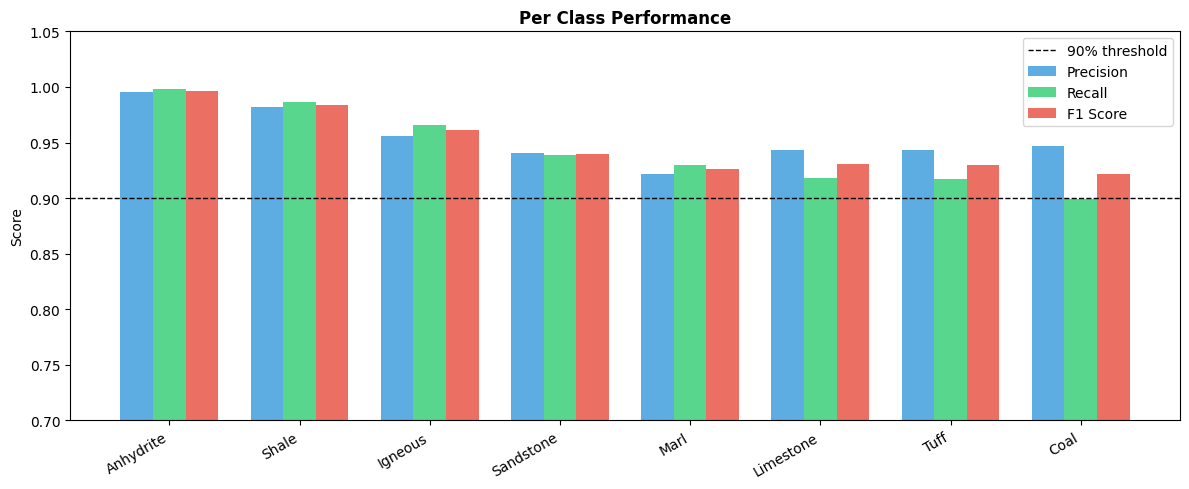

💾 Saved → per_class_performance.png


In [3]:
# Cell 3 - Per Class Performance
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred,
         target_names=le_target.classes_,
         output_dict=True)

report_df = pd.DataFrame(report).T.round(3)
report_df = report_df.drop(["accuracy", "macro avg", "weighted avg"])
report_df["support"] = report_df["support"].astype(int)
report_df = report_df.sort_values("recall", ascending=False)

print("📊 Per Class Performance:\n")
print(f"{'Class':<12} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>10}")
print(f"{'-'*52}")
for cls, row in report_df.iterrows():
    status = "✅" if row["recall"] >= 0.90 else \
             "⚠️" if row["recall"] >= 0.80 else "❌"
    print(f"  {cls:<12} {row['precision']:>9.2%} {row['recall']:>7.2%} "
          f"{row['f1-score']:>7.2%} {row['support']:>9,}  {status}")

# Plot
plt.figure(figsize=(12, 5))
x      = range(len(report_df))
width  = 0.25
colors = ["#3498db", "#2ecc71", "#e74c3c"]

plt.bar([i - width   for i in x], report_df["precision"],
        width=width, label="Precision", color="#3498db", alpha=0.8)
plt.bar([i           for i in x], report_df["recall"],
        width=width, label="Recall",    color="#2ecc71", alpha=0.8)
plt.bar([i + width   for i in x], report_df["f1-score"],
        width=width, label="F1 Score",  color="#e74c3c", alpha=0.8)

plt.axhline(y=0.90, color="black", linestyle="--",
            linewidth=1, label="90% threshold")
plt.xticks(x, report_df.index, rotation=30, ha="right")
plt.ylabel("Score")
plt.ylim(0.7, 1.05)
plt.title("Per Class Performance", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/per_class_performance.png", dpi=150)
plt.show()
print("💾 Saved → per_class_performance.png")

Each ROW  = Actual class (ground truth)
Each COL  = Predicted class (model output)
Diagonal  = Correct predictions ✅
Off-diagonal = Mistakes ❌

Anhydrite → 99.8% correct ✅ nearly perfect
Shale     → 98.6% correct ✅ excellent
Coal      → 89.9% correct ⚠️ 5.9% confused with Anhydrite

Limestone → 91.8% correct
            5.0%  → predicted as Shale ⚠️
            2.0%  → predicted as Marl  ⚠️

Sandstone → 93.9% correct
            5.1%  → predicted as Shale ⚠️

Tuff      → 91.7% correct
            5.6%  → predicted as Shale ⚠️

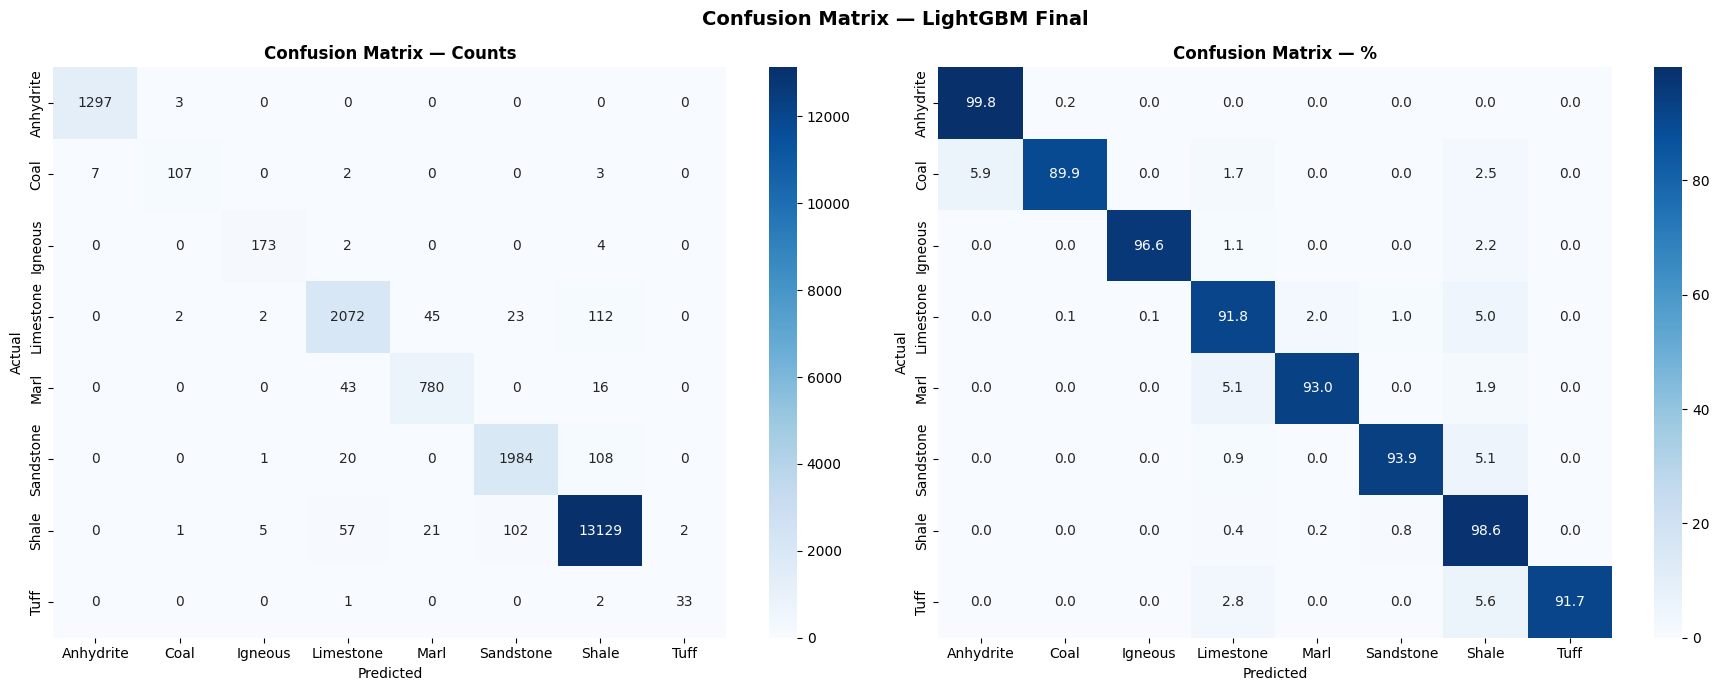

💾 Saved → confusion_matrix_final.png


In [4]:
# Cell 4 - Confusion Matrix
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            ax=axes[0])
axes[0].set_title("Confusion Matrix — Counts",
                  fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Percentages
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            ax=axes[1])
axes[1].set_title("Confusion Matrix — %",
                  fontweight="bold")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.suptitle("Confusion Matrix — LightGBM Final",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/confusion_matrix_final.png", dpi=150)
plt.show()
print("💾 Saved → confusion_matrix_final.png")

TOP 3 — Most Powerful:
GR       52,304  → gamma ray — best lithology indicator
DEPTH_MD 48,190  → depth controls rock type
DTC      45,990  → sonic log — rock hardness

MIDDLE — Supporting:
CALI, RHOB, DRHO, RDEP, RMED, NPHI, PEF
→ all contributing meaningfully

BOTTOM — Least useful:
FORMATION 13,222  → some help
GROUP      6,945  → small contribution
WELL       5,826  → least useful

Top 10 features → cover 94.1% of decisions
FORMATION + GROUP + WELL → only 5.9%

→ Confirms our earlier discussion!
  These 3 could be dropped with
  minimal accuracy loss

📊 Feature Importance:

Feature        Importance   Cumulative
--------------------------------------
  GR               52,304       11.8%  ████████████████████
  DEPTH_MD         48,190       22.8%  ██████████████████
  DTC              45,990       33.2%  █████████████████
  CALI             43,750       43.1%  ████████████████
  RHOB             41,598       52.5%  ███████████████
  DRHO             40,580       61.7%  ███████████████
  RDEP             37,938       70.3%  ██████████████
  RMED             35,631       78.4%  █████████████
  NPHI             35,568       86.4%  █████████████
  PEF              33,860       94.1%  ████████████
  FORMATION        13,222       97.1%  █████
  GROUP             6,945       98.7%  ██
  WELL              5,826      100.0%  ██


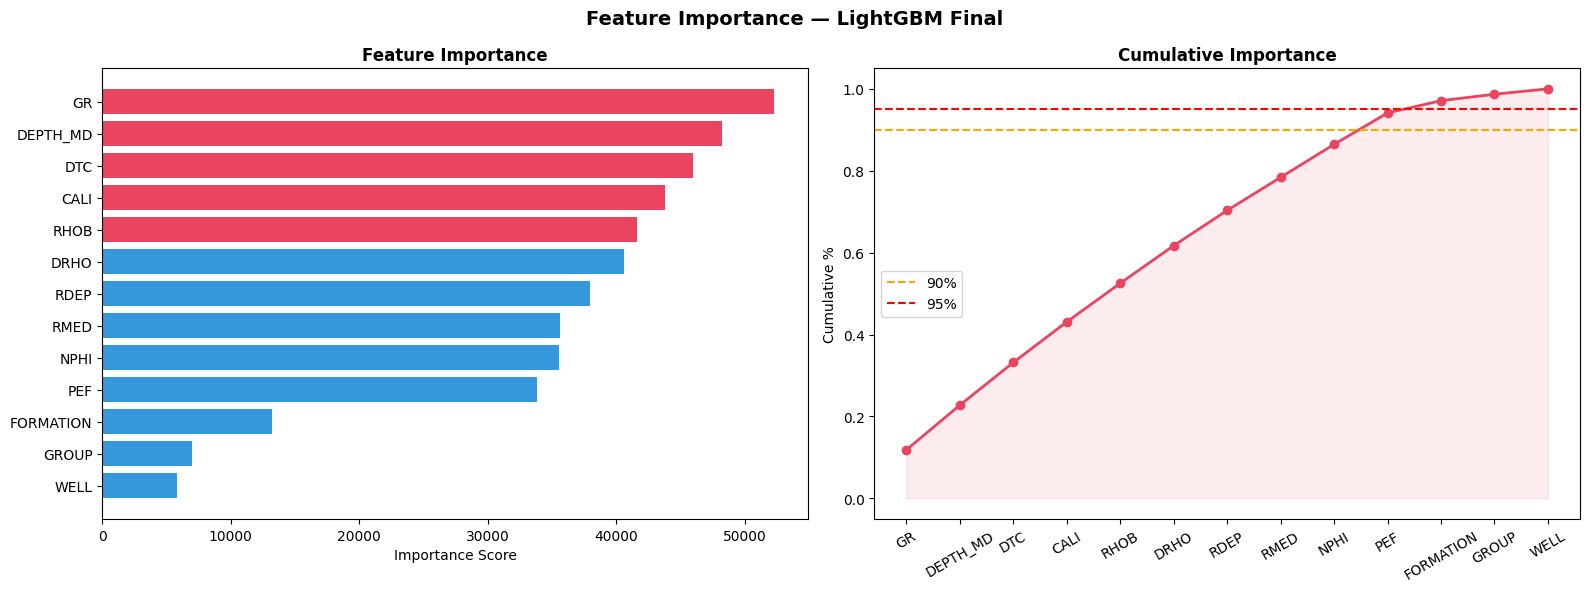

💾 Saved → feature_importance_final.png


In [5]:
# Cell 5 - Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature"   : FEATURES_13,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

# Cumulative importance
importance_df["Cumulative"] = importance_df["Importance"].cumsum()
importance_df["Cumulative"] = importance_df["Cumulative"] / importance_df["Importance"].sum()

print("📊 Feature Importance:\n")
print(f"{'Feature':<12} {'Importance':>12} {'Cumulative':>12}")
print(f"{'-'*38}")
for _, row in importance_df.iterrows():
    bar = "█" * int(row["Importance"] / importance_df["Importance"].max() * 20)
    print(f"  {row['Feature']:<12} {row['Importance']:>10,}  "
          f"{row['Cumulative']:>10.1%}  {bar}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ["#e94560" if i < 5 else "#3498db"
          for i in range(len(importance_df))]
axes[0].barh(importance_df["Feature"],
             importance_df["Importance"],
             color=colors)
axes[0].set_title("Feature Importance", fontweight="bold")
axes[0].set_xlabel("Importance Score")
axes[0].invert_yaxis()

# Cumulative
axes[1].plot(importance_df["Feature"],
             importance_df["Cumulative"],
             marker="o", color="#e94560", linewidth=2)
axes[1].axhline(y=0.90, color="orange",
                linestyle="--", label="90%")
axes[1].axhline(y=0.95, color="red",
                linestyle="--", label="95%")
axes[1].fill_between(importance_df["Feature"],
                     importance_df["Cumulative"],
                     alpha=0.1, color="#e94560")
axes[1].set_title("Cumulative Importance", fontweight="bold")
axes[1].set_ylabel("Cumulative %")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.suptitle("Feature Importance — LightGBM Final",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/feature_importance_final.png", dpi=150)
plt.show()
print("💾 Saved → feature_importance_final.png")

📊 Misclassification Summary:

   Total samples   : 20,159
   Correct         : 19,575  (97.10%)
   Wrong           : 584   (2.90%)

🔍 Top Misclassification Pairs:

Actual         Predicted        Count        %
------------------------------------------------
  Limestone    → Shale            112    0.56%
  Sandstone    → Shale            108    0.54%
  Shale        → Sandstone        102    0.51%
  Shale        → Limestone         57    0.28%
  Limestone    → Marl              45    0.22%
  Marl         → Limestone         43    0.21%
  Limestone    → Sandstone         23    0.11%
  Shale        → Marl              21    0.10%
  Sandstone    → Limestone         20    0.10%
  Marl         → Shale             16    0.08%


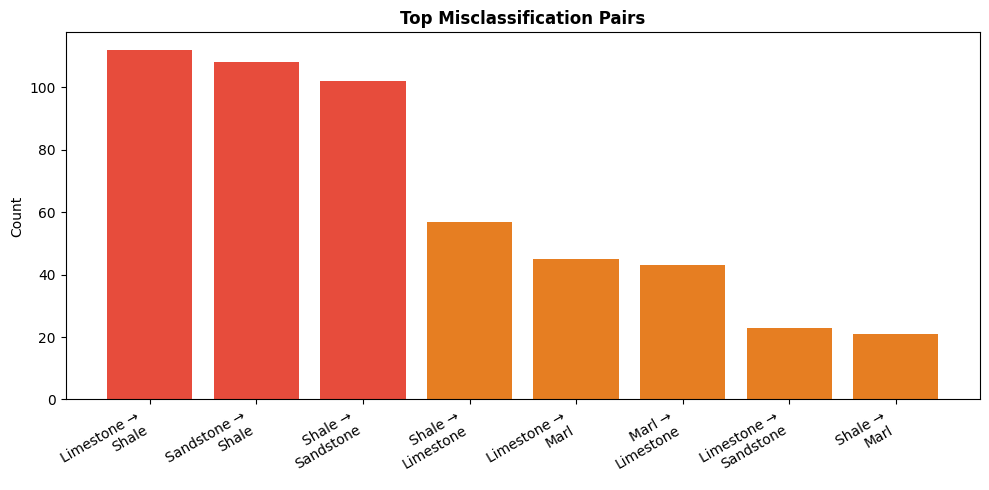

💾 Saved → misclassifications.png


In [6]:
# Cell 6 - Misclassification Analysis
df_test = X_test[FEATURES_13].copy()
df_test["Actual"]    = le_target.inverse_transform(y_test)
df_test["Predicted"] = le_target.inverse_transform(y_pred)
df_test["Correct"]   = df_test["Actual"] == df_test["Predicted"]

# Overall
total      = len(df_test)
correct    = df_test["Correct"].sum()
wrong      = total - correct

print(f"📊 Misclassification Summary:\n")
print(f"   Total samples   : {total:,}")
print(f"   Correct         : {correct:,}  ({correct/total*100:.2f}%)")
print(f"   Wrong           : {wrong:,}   ({wrong/total*100:.2f}%)")

# Top misclassification pairs
print(f"\n🔍 Top Misclassification Pairs:\n")
wrong_df = df_test[~df_test["Correct"]]
pairs    = wrong_df.groupby(["Actual", "Predicted"])\
                   .size().reset_index(name="Count")\
                   .sort_values("Count", ascending=False)

print(f"{'Actual':<14} {'Predicted':<14} {'Count':>7} {'%':>8}")
print(f"{'-'*48}")
for _, row in pairs.head(10).iterrows():
    pct = row["Count"] / total * 100
    print(f"  {row['Actual']:<12} → {row['Predicted']:<12} "
          f"{row['Count']:>7,}  {pct:>6.2f}%")

# Plot
plt.figure(figsize=(10, 5))
top_pairs  = pairs.head(8)
labels     = [f"{r['Actual']} →\n{r['Predicted']}"
              for _, r in top_pairs.iterrows()]
colors     = ["#e74c3c" if r["Count"] > 100 else "#e67e22"
              for _, r in top_pairs.iterrows()]
plt.bar(labels, top_pairs["Count"], color=colors)
plt.title("Top Misclassification Pairs", fontweight="bold")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/misclassifications.png", dpi=150)
plt.show()
print("💾 Saved → misclassifications.png")

In [7]:
# Cell 7 - Predict on Unlabeled Data
from sklearn.preprocessing import LabelEncoder

df_unlabeled = pd.read_csv(UNLABELED_FILE, low_memory=False)

print(f"📋 Unlabeled data loaded!")
print(f"   Shape : {df_unlabeled.shape}")
print(f"   Wells : {df_unlabeled['WELL'].nunique()}\n")

# Drop irrelevant columns
cols_to_drop = [c for c in COLUMNS_TO_DROP if c in df_unlabeled.columns]
df_unlabeled.drop(columns=cols_to_drop, inplace=True)

# Encode categoricals
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_unlabeled[col] = le.fit_transform(
                        df_unlabeled[col].astype(str))

# Impute missing
df_unlabeled[NUMERICAL_FEATURES] = df_unlabeled\
    .groupby("WELL")[NUMERICAL_FEATURES]\
    .transform(lambda x: x.fillna(x.median()))
df_unlabeled[NUMERICAL_FEATURES] = df_unlabeled[NUMERICAL_FEATURES]\
    .fillna(df_unlabeled[NUMERICAL_FEATURES].median())

# Predict
X_unlabeled   = df_unlabeled[FEATURES_13]
predictions   = model.predict(X_unlabeled)
probabilities = model.predict_proba(X_unlabeled)

df_unlabeled["PREDICTED_LITHOLOGY"] = le_target\
    .inverse_transform(predictions)
df_unlabeled["CONFIDENCE"]          = probabilities\
    .max(axis=1).round(3)

print(f"🎯 Prediction Distribution:\n")
pred_counts = df_unlabeled["PREDICTED_LITHOLOGY"].value_counts()
total       = len(df_unlabeled)
for cls, count in pred_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"   {cls:<12} {count:>7,}  {pct:>5.1f}%  {bar}")

print(f"\n📊 Confidence Stats:")
print(f"   Mean   : {df_unlabeled['CONFIDENCE'].mean():.3f}")
print(f"   Median : {df_unlabeled['CONFIDENCE'].median():.3f}")
print(f"   Min    : {df_unlabeled['CONFIDENCE'].min():.3f}")
print(f"   Max    : {df_unlabeled['CONFIDENCE'].max():.3f}")

# Save
df_unlabeled.to_csv(f"{OUTPUT_PATH}/predictions.csv", index=False)
print(f"\n💾 Saved → data/output/predictions.csv")

📋 Unlabeled data loaded!
   Shape : (136786, 28)
   Wells : 10

🎯 Prediction Distribution:

   Shale         98,301   71.9%  ███████████████████████████████████
   Limestone     26,625   19.5%  █████████
   Sandstone     10,953    8.0%  ████
   Marl             678    0.5%  
   Tuff             229    0.2%  

📊 Confidence Stats:
   Mean   : 0.841
   Median : 0.916
   Min    : 0.257
   Max    : 1.000

💾 Saved → data/output/predictions.csv


In [9]:
# Cell 8 - Final Evaluation Report
print("=" * 60)
print("       📋 FINAL EVALUATION REPORT")
print("       Lithofacies Classification — FORCE 2020")
print("=" * 60)

print(f"""
📊 DATASET:
   Total labeled rows   : 121,424
   Corrupted rows dropped: 19,160  (Unknown well)
   Clean rows used      : 100,793
   Train rows           : 80,634   (80%)
   Test  rows           : 20,159   (20%)
   Features             : 13
   Classes              : 8

🏆 MODEL PERFORMANCE:
   Algorithm            : LightGBM
   Train Accuracy       : 99.97%
   Test  Accuracy       : 97.10%  ✅ Target achieved!
   Balanced Accuracy    : 94.41%
   Gap                  : 2.86%   ✅ Acceptable

📊 PER CLASS PERFORMANCE:
   Anhydrite  → Recall: 99.8%  ✅
   Shale      → Recall: 98.6%  ✅
   Igneous    → Recall: 96.6%  ✅
   Marl       → Recall: 93.0%  ✅
   Sandstone  → Recall: 93.9%  ✅
   Limestone  → Recall: 91.8%  ✅
   Tuff       → Recall: 91.7%  ✅
   Coal       → Recall: 89.9%  ⚠️

🔑 KEY FEATURES (Top 5):
   1. GR        → 11.8% importance
   2. DEPTH_MD  → 22.8% cumulative
   3. DTC       → 33.2% cumulative
   4. CALI      → 43.1% cumulative
   5. RHOB      → 52.5% cumulative

⚠️  MISCLASSIFICATIONS (2.90%):
   Most common between similar rocks:
   Limestone ↔ Shale    → 0.84%
   Sandstone ↔ Shale    → 1.05%
   Limestone ↔ Marl     → 0.43%

🔮 UNLABELED PREDICTIONS:
   Total predicted      : 136,786
   Shale                : 71.9%
   Limestone            : 19.5%
   Sandstone            :  8.0%
   Mean confidence      : 84.1%
   Median confidence    : 91.6%

🔑 KEY LESSON:
   Path to 97%+ was DATA QUALITY
   not model complexity!
   Removing 19,160 corrupted rows
   jumped accuracy from 91.57% → 97.10%
""")
print("=" * 60)
print("  ✅ Evaluation Complete!")
print("  📓 Next → Build Pipeline in src/")
print("=" * 60)

       📋 FINAL EVALUATION REPORT
       Lithofacies Classification — FORCE 2020

📊 DATASET:
   Total labeled rows   : 121,424
   Corrupted rows dropped: 19,160  (Unknown well)
   Clean rows used      : 100,793
   Train rows           : 80,634   (80%)
   Test  rows           : 20,159   (20%)
   Features             : 13
   Classes              : 8

🏆 MODEL PERFORMANCE:
   Algorithm            : LightGBM
   Train Accuracy       : 99.97%
   Test  Accuracy       : 97.10%  ✅ Target achieved!
   Balanced Accuracy    : 94.41%
   Gap                  : 2.86%   ✅ Acceptable

📊 PER CLASS PERFORMANCE:
   Anhydrite  → Recall: 99.8%  ✅
   Shale      → Recall: 98.6%  ✅
   Igneous    → Recall: 96.6%  ✅
   Marl       → Recall: 93.0%  ✅
   Sandstone  → Recall: 93.9%  ✅
   Limestone  → Recall: 91.8%  ✅
   Tuff       → Recall: 91.7%  ✅
   Coal       → Recall: 89.9%  ⚠️

🔑 KEY FEATURES (Top 5):
   1. GR        → 11.8% importance
   2. DEPTH_MD  → 22.8% cumulative
   3. DTC       → 33.2% cumulative
   4. C

Most misclassifications occur between lithologies with gradational mineralogical composition (e.g., marl–limestone, shale–sandstone), indicating the model is capturing realistic geological transitions rather than random error.

# Test any file here 

In [3]:
# Batch CSV Prediction from data/test/
import pandas as pd
import joblib
import glob
import os
import sys
from sklearn.preprocessing import LabelEncoder

sys.path.append("D:/Python/Lithofacies_Classification_NMM/src")
from config import *

TEST_PATH   = "D:/Python/Lithofacies_Classification_NMM/data/test"
OUTPUT_PATH = "D:/Python/Lithofacies_Classification_NMM/data/output"
os.makedirs(OUTPUT_PATH, exist_ok=True)

model     = joblib.load(f"{MODEL_PATH}/best_model.pkl")
le_target = joblib.load(f"{MODEL_PATH}/le_target.pkl")

test_files = glob.glob(f"{TEST_PATH}/*.csv")
print(f"Found {len(test_files)} file(s) in data/test/\n")
print("=" * 55)

all_results = []

for file in test_files:
    fname = os.path.basename(file)
    print(f"\nProcessing : {fname}")

    df_new = pd.read_csv(file, low_memory=False)
    print(f"   Rows loaded : {len(df_new):,}")
    print(f"   Missing vals: {df_new.isnull().sum().sum()}")

    # Drop irrelevant columns if present
    cols = [c for c in COLUMNS_TO_DROP if c in df_new.columns]
    df_new.drop(columns=cols, inplace=True)

    # Encode categoricals
    for col in CATEGORICAL_FEATURES:
        if col in df_new.columns:
            le = LabelEncoder()
            df_new[col] = le.fit_transform(
                          df_new[col].astype(str))
        else:
            df_new[col] = 0

    # Impute missing
    df_new[NUMERICAL_FEATURES] = df_new[NUMERICAL_FEATURES]\
        .fillna(df_new[NUMERICAL_FEATURES].median())

    # Predict
    preds  = model.predict(df_new[FEATURES_13])
    probas = model.predict_proba(df_new[FEATURES_13])

    df_new["PREDICTED_LITHOLOGY"] = le_target\
        .inverse_transform(preds)
    df_new["CONFIDENCE"] = probas.max(axis=1).round(3)

    # Summary
    print(f"\n   Prediction Distribution:")
    counts = df_new["PREDICTED_LITHOLOGY"].value_counts()
    total  = len(df_new)
    for cls, count in counts.items():
        pct = count / total * 100
        bar = "█" * int(pct / 3)
        print(f"      {cls:<12} {count:>5,}  {pct:>5.1f}%  {bar}")

    print(f"\n   Confidence Stats:")
    print(f"      Mean   : {df_new['CONFIDENCE'].mean():.3f}")
    print(f"      Median : {df_new['CONFIDENCE'].median():.3f}")
    print(f"      Min    : {df_new['CONFIDENCE'].min():.3f}")
    print(f"      Max    : {df_new['CONFIDENCE'].max():.3f}")

    # Save individual result
    out_name = fname.replace(".csv", "_predictions.csv")
    df_new.to_csv(f"{OUTPUT_PATH}/{out_name}", index=False)
    print(f"\n   Saved : data/output/{out_name}")
    print("=" * 55)

    all_results.append(df_new)

# Save combined results
combined = pd.concat(all_results, ignore_index=True)
combined.to_csv(f"{OUTPUT_PATH}/all_test_predictions.csv",
                index=False)

print(f"""
SUMMARY:
   Files processed : {len(test_files)}
   Total rows      : {len(combined):,}
   Saved combined  : data/output/all_test_predictions.csv
""")

✅ Config loaded!
Found 3 file(s) in data/test/


Processing : test_well_A.csv
   Rows loaded : 500
   Missing vals: 131

   Prediction Distribution:
      Shale          360   72.0%  ████████████████████████
      Limestone       81   16.2%  █████
      Sandstone       32    6.4%  ██
      Marl            22    4.4%  █
      Igneous          4    0.8%  
      Tuff             1    0.2%  

   Confidence Stats:
      Mean   : 0.810
      Median : 0.871
      Min    : 0.308
      Max    : 1.000

   Saved : data/output/test_well_A_predictions.csv

Processing : test_well_B.csv
   Rows loaded : 300
   Missing vals: 74

   Prediction Distribution:
      Limestone      161   53.7%  █████████████████
      Shale          126   42.0%  ██████████████
      Sandstone        6    2.0%  
      Marl             6    2.0%  
      Igneous          1    0.3%  

   Confidence Stats:
      Mean   : 0.751
      Median : 0.784
      Min    : 0.307
      Max    : 0.999

   Saved : data/output/test_well_B_pre